# Tutorial AAMAS 2026

Welcome to the hands-on session! Here's how this notebook works:

1. **Predict.** Before each result we'll commit a guess via a small poll.
2. **Run.** Execute the cell and see whether the algorithm agrees with you.
3. **Play.** Sliders let you change the number of traces to learn from, and watch the metrics react.
4. **Compete.** We end with a leaderboard challenge — best solver wins.

Tip: in Colab/Jupyter, if you want to run all cells at once, click `Cell → Run All` only *after* you've made your predictions in each section.

In [ ]:
%pip install amlgym ipywidgets matplotlib pandas > /dev/null 2>&1

In [ ]:
# Shared utilities used throughout the notebook
import re
import difflib
import ipywidgets as widgets
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, HTML, Markdown

# ggplot style for every plot
plt.style.use("ggplot")

# ---------- polls & reveals ----------
_POLL_HTML = """<div style='border-left:4px solid #6f42c1;background:#f3eefb;
padding:12px 16px;margin:10px 0;border-radius:6px;
font-family:-apple-system,BlinkMacSystemFont,"Segoe UI",sans-serif;'>
<div style='font-size:15px;font-weight:600;color:#6f42c1;margin-bottom:4px;
letter-spacing:0.3px;'>{header}</div>
<div style='color:#24292f;font-size:14px;line-height:1.45;'>{question}</div></div>"""

def make_poll(question, options, header="\U0001F52E Cast your prediction"):
    """Render a styled poll. Returns the widget so we can read .value later."""
    display(HTML(_POLL_HTML.format(header=header, question=question)))
    w = widgets.RadioButtons(options=options, layout=widgets.Layout(width="auto"))
    display(w)
    return w

def reveal(poll, truth, formatter=str):
    """Reveal whether the audience's guess matches the computed truth."""
    chosen = poll.value
    if chosen == truth:
        accent, bg, border = "#15803d", "#dcfce7", "#16a34a"
        icon, msg = "\U0001F31F", "Spot on!"
    else:
        accent, bg, border = "#92400e", "#fef3c7", "#d97706"
        icon, msg = "\U0001F9ED", "Off the mark - but now you know."
    truth_str = formatter(truth) if formatter is not str else truth
    display(HTML(
        "<div style='border-left:4px solid " + border + ";background:" + bg + ";"
        "padding:12px 16px;margin:10px 0;border-radius:6px;"
        "font-family:-apple-system,BlinkMacSystemFont,\"Segoe UI\",sans-serif;font-size:14px;'>"
        "<div style='font-size:15px;font-weight:700;color:" + accent + ";margin-bottom:6px;'>"
        + icon + " " + msg + "</div>"
        "<div style='color:#374151;'><b>Your guess:</b> " + str(chosen) + "</div>"
        "<div style='color:#374151;'><b>Truth:</b> " + str(truth_str) + "</div></div>"
    ))

def pick_bucket(value, options):
    """Return the poll option whose numeric range contains ``value``."""
    for opt in options:
        if re.search(r"\bexactly\s+1", opt, re.I) and value >= 1.0 - 1e-9:
            return opt
        if re.search(r"\bbelow\b", opt, re.I):
            nums = re.findall(r"\d+(?:\.\d+)?", opt)
            if nums and value < float(nums[0]):
                return opt
        nums = re.findall(r"\d+(?:\.\d+)?", opt)
        if len(nums) >= 2:
            lo, hi = float(nums[0]), float(nums[1])
            if lo <= value < hi:
                return opt
        if len(nums) == 1 and "perfect" in opt.lower() and value >= float(nums[0]) - 1e-9:
            return opt
    return options[-1]


def _tokenize(text):
    text = re.sub(r";[^\n]*", "", text)
    return re.findall(r"\(|\)|[^\s()]+", text)

def _parse_all(tokens):
    def helper(i):
        if tokens[i] == "(":
            out, i = [], i + 1
            while i < len(tokens) and tokens[i] != ")":
                child, i = helper(i)
                out.append(child)
            return out, i + 1
        return tokens[i], i + 1
    forms, i = [], 0
    while i < len(tokens):
        f, i = helper(i)
        forms.append(f)
    return forms

def _flat(node):
    if isinstance(node, str):
        return node
    return "(" + " ".join(_flat(c) for c in node) + ")"

def _canon_var_list(items):
    """Rename ?vars left-to-right to ?p1, ?p2, ... ; return (new_items, map)."""
    out, m, idx, j = [], {}, 0, 0
    while j < len(items):
        tok = items[j]
        if isinstance(tok, str) and tok.startswith("?"):
            idx += 1
            new = "?p{}".format(idx)
            m[tok] = new
            out.append(new)
            j += 1
            if j + 1 < len(items) and items[j] == "-":
                out.extend(["-", items[j + 1]])
                j += 2
        else:
            out.append(tok)
            j += 1
    return out, m

def _canon_predicate_decl(pred):
    if not (isinstance(pred, list) and pred):
        return pred
    new_args, _ = _canon_var_list(pred[1:])
    return [pred[0]] + new_args

def _sort_and(node):
    if isinstance(node, list) and node and isinstance(node[0], str) and node[0] == "and":
        kids = [_sort_and(c) for c in node[1:]]
        kids.sort(key=_flat)
        return ["and"] + kids
    if isinstance(node, list):
        return [_sort_and(c) if isinstance(c, list) else c for c in node]
    return node

def _canon_action(action):
    if not (isinstance(action, list) and action and action[0] == ":action"):
        return action
    name = action[1]
    kv, i = {}, 2
    while i < len(action) - 1:
        kv[action[i]] = action[i + 1]
        i += 2
    canon_params, params_map = [], {}
    if ":parameters" in kv and isinstance(kv[":parameters"], list):
        canon_params, params_map = _canon_var_list(kv[":parameters"])
    def rename(n):
        if isinstance(n, str):
            return params_map.get(n, n)
        return [rename(c) for c in n]
    out = [":action", name]
    if ":parameters" in kv:
        out += [":parameters", canon_params]
    if ":precondition" in kv:
        out += [":precondition", _sort_and(rename(kv[":precondition"]))]
    if ":effect" in kv:
        out += [":effect", _sort_and(rename(kv[":effect"]))]
    return out

def _canon_predicates_block(block):
    if not (isinstance(block, list) and block and block[0] == ":predicates"):
        return block
    preds = [_canon_predicate_decl(p) for p in block[1:]]
    preds.sort(key=_flat)
    return [":predicates"] + preds

def _render(node, indent=0):
    if isinstance(node, str):
        return node
    if not node:
        return "()"
    head = node[0]
    if isinstance(head, str) and head == "and" and len(node) > 1:
        sub_ind = "  " * (indent + 1)
        body = "\n".join(sub_ind + _render(c, indent + 1) for c in node[1:])
        return "(and\n" + body + ")"
    if isinstance(head, str) and head == ":action":
        ind = "  " * (indent + 1)
        out = "(:action " + str(node[1])
        i = 2
        while i < len(node) - 1:
            kw, val = node[i], node[i + 1]
            val_str = _render(val, indent + 2)
            if "\n" in val_str:
                out += "\n" + ind + kw + "\n" + ind + "  " + val_str.replace("\n", "\n  ")
            else:
                out += "\n" + ind + kw + " " + val_str
            i += 2
        return out + ")"
    if isinstance(head, str) and head == ":predicates":
        ind = "  " * (indent + 1)
        body = "\n".join(ind + _render(p, indent + 1) for p in node[1:])
        return "(:predicates\n" + body + ")"
    parts = [_render(c, indent + 1) if isinstance(c, list) else c for c in node]
    return "(" + " ".join(parts) + ")"

def pddl_canonical(text):
    """Return a canonical, diff-friendly PDDL string."""
    try:
        forms = _parse_all(_tokenize(text.lower()))
    except Exception:
        return text
    lines = []
    for form in forms:
        if not isinstance(form, list):
            continue
        if form and form[0] == "define":
            lines.append("(define")
            non_actions, actions = [], []
            for elem in form[1:]:
                if isinstance(elem, list) and elem and elem[0] == ":action":
                    actions.append(_canon_action(elem))
                elif isinstance(elem, list) and elem and elem[0] == ":predicates":
                    non_actions.append(_canon_predicates_block(elem))
                else:
                    non_actions.append(elem)
            actions.sort(key=lambda a: a[1] if len(a) > 1 else "")
            for elem in non_actions:
                rendered = _render(elem, 1)
                lines.append("  " + rendered.replace("\n", "\n  "))
            for elem in actions:
                rendered = _render(elem, 1)
                lines.append("")
                lines.append("  " + rendered.replace("\n", "\n  "))
            lines.append(")")
        else:
            lines.append(_render(form))
    return "\n".join(lines) + "\n"

_DIFF_CSS = """<style>
table.diff{font-family:"SF Mono",Menlo,Consolas,monospace;font-size:12px;
border-collapse:collapse;width:100%;border:1px solid #d0d7de;border-radius:6px;
overflow:hidden;margin:8px 0;background:#ffffff;table-layout:fixed;}
table.diff td{padding:1px 8px;vertical-align:top;white-space:pre-wrap;
border:none;line-height:1.45;word-break:break-word;}
table.diff th{background:#f6f8fa;color:#24292f;font-weight:600;
padding:8px 10px;border-bottom:1px solid #d0d7de;text-align:left;}
table.diff td.diff_header{background:#f6f8fa;color:#8b949e;
text-align:right;width:36px;user-select:none;font-weight:500;}
table.diff td.diff_next,table.diff td.diff_next a{display:none;}
.diff_add{background:#d1f4d8;color:#0f5132;}
.diff_chg{background:#fff3bf;color:#7a5d00;}
.diff_sub{background:#ffd0d0;color:#82071e;}
</style>"""

def html_diff(learned_path, ref_path, title_l="Learned", title_r="Reference"):
    """Side-by-side, syntax-aware diff of two PDDL files."""
    with open(learned_path) as f1, open(ref_path) as f2:
        l1 = pddl_canonical(f1.read()).splitlines(keepends=True)
        l2 = pddl_canonical(f2.read()).splitlines(keepends=True)
    table = difflib.HtmlDiff(wrapcolumn=80).make_table(
        l1, l2, fromdesc=title_l, todesc=title_r,
        context=False,
    )
    display(HTML(_DIFF_CSS + table))

import re
from html import escape
from itertools import zip_longest
from IPython.display import display, HTML

# ---- styling: same shape as html_diff, no diff colors, dark readable text ----
_SXS_CSS = """<style>
table.pddl-sxs{font-family:"JetBrains Mono","SF Mono",Menlo,Consolas,monospace;
font-size:12.5px;border-collapse:collapse;width:100%;border:1px solid #d0d7de;
border-radius:8px;overflow:hidden;margin:8px 0;background:#ffffff;color:#1f2937;
table-layout:fixed;}
table.pddl-sxs th{background:#f6f8fa;color:#24292f;font-weight:600;
padding:10px 12px;border-bottom:1px solid #d0d7de;text-align:left;}
table.pddl-sxs td{padding:2px 10px;vertical-align:top;white-space:pre-wrap;
border:none;line-height:1.55;word-break:break-word;color:#1f2937;}
table.pddl-sxs td.ln{background:#f6f8fa;color:#8b949e;text-align:right;
user-select:none;font-weight:500;border-right:1px solid #eaeef2;}
table.pddl-sxs tr:hover td.code{background:#f9fafb;}
</style>"""

# Color rules — tuned for white background, GitHub-light palette
_PDDL_LOGIC   = {"and", "or", "not", "when", "forall", "exists", "imply"}
_PDDL_DEFINE  = {"define", "domain", "problem"}

def _pddl_highlight(line):
    """Tokenize a PDDL line and wrap each token in a colored span."""
    if not line:
        return "&nbsp;"
    out, i, next_is_head = [], 0, False
    while i < len(line):
        ch = line[i]
        # comment to end of line
        if ch == ";":
            out.append(f"<span style='color:#6e7781;font-style:italic'>"
                       f"{escape(line[i:])}</span>")
            break
        # whitespace preserved verbatim
        if ch in " \t":
            j = i
            while j < len(line) and line[j] in " \t":
                j += 1
            out.append(line[i:j])
            i = j
            continue
        # parens (muted)
        if ch == "(":
            out.append("<span style='color:#8b949e'>(</span>")
            i += 1; next_is_head = True
            continue
        if ch == ")":
            out.append("<span style='color:#8b949e'>)</span>")
            i += 1
            continue
        # any other token
        j = i
        while j < len(line) and line[j] not in " \t()":
            j += 1
        tok = line[i:j]; i = j
        low = tok.lower()
        if tok.startswith("?"):                       # variable
            style = "color:#0969da"
        elif tok.startswith(":"):                     # :keyword (incl. :strips, :typing, :action ...)
            style = "color:#8250df;font-weight:600"
        elif low in _PDDL_LOGIC:                      # and, not, when, ...
            style = "color:#cf222e;font-weight:600"
        elif low in _PDDL_DEFINE:                     # define, domain, problem
            style = "color:#8250df;font-weight:700"
        elif tok == "-":                              # type separator
            style = "color:#8b949e"
        elif next_is_head:                            # predicate / action / operator head
            style = "color:#953800;font-weight:500"
        else:                                          # objects, types — default dark slate
            style = "color:#1f2937"
        out.append(f"<span style='{style}'>{escape(tok)}</span>")
        next_is_head = False
    return "".join(out) or "&nbsp;"

def html_side_by_side(left_path, right_path,
                      title_l="Learned", title_r="Reference"):
    """Print two PDDL files side by side with syntax highlighting (no diff)."""
    with open(left_path)  as f1: l = pddl_canonical(f1.read()).splitlines()
    with open(right_path) as f2: r = pddl_canonical(f2.read()).splitlines()
    rows = []
    for n, (a, b) in enumerate(zip_longest(l, r, fillvalue=""), start=1):
        rows.append(
            "<tr>"
            f"<td class='ln'>{n}</td><td class='code'>{_pddl_highlight(a)}</td>"
            f"<td class='ln'>{n}</td><td class='code'>{_pddl_highlight(b)}</td>"
            "</tr>"
        )
    table = (
        "<table class='pddl-sxs'>"
        "<colgroup><col style='width:36px'><col>"
        "<col style='width:36px'><col></colgroup>"
        f"<thead><tr><th colspan='2'>{escape(title_l)}</th>"
        f"<th colspan='2'>{escape(title_r)}</th></tr></thead>"
        "<tbody>" + "".join(rows) + "</tbody></table>"
    )
    display(HTML(_SXS_CSS + table))

# ---------- plotting helper ----------
_GG_COLORS = ["#e24a33", "#348abd", "#988ed5", "#fbc15e", "#777777", "#8eba42"]

def bar_compare(values, title, ylabel, ylim=(0, 1)):
    with plt.style.context("ggplot"):
        fig, ax = plt.subplots(figsize=(6, 3.5))
        labels = list(values.keys())
        ax.bar(labels, [values[k] for k in labels],
               color=_GG_COLORS[: len(labels)])
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        if ylim:
            ax.set_ylim(*ylim)
        for i, v in enumerate(values.values()):
            ax.text(i, v + 0.02, "{:.2f}".format(v), ha="center", fontsize=10,
                    color="#333333")
        plt.tight_layout()
        plt.show()

# Silence the unified-planning credits banner
import unified_planning
from unified_planning import shortcuts
shortcuts.get_environment().credits_stream = None


## 1. Exploring the benchmarks

AMLGym ships dozens of IPC domains. Let's first see what's available.

In [55]:
from amlgym.benchmarks import print_domains
print_domains()

['barman',
 'blocksworld',
 'childsnack',
 'depots',
 'driverlog',
 'elevators',
 'ferry',
 'floortile',
 'goldminer',
 'grid',
 'grippers',
 'hanoi',
 'matchingbw',
 'miconic',
 'nomystery',
 'npuzzle',
 'parking',
 'rovers',
 'satellite',
 'sokoban',
 'spanner',
 'tpp',
 'transport',
 'visitall',
 'zenotravel']


Pick a domain to inspect: let's start with **blocksworld**.

In [56]:
from amlgym.benchmarks import get_domain_path, get_domain
domain_path = get_domain_path('blocksworld')
print(domain_path)

/usr/local/lib/python3.12/dist-packages/amlgym/benchmarks/domains/blocksworld.pddl


In [ ]:
domain_pddl = get_domain('blocksworld')
print(domain_pddl)

Each domain comes with **10 training trajectories** generated from a known reference model. These are what the learners get to see.

In [57]:
from amlgym.benchmarks import get_trajectories_path, get_trajectories, get_problems_path
from pprint import pprint

trajectory_paths = get_trajectories_path('blocksworld')
pprint(trajectory_paths)

['/usr/local/lib/python3.12/dist-packages/amlgym/benchmarks/trajectories/learning/blocksworld/0_blocksworld_traj',
 '/usr/local/lib/python3.12/dist-packages/amlgym/benchmarks/trajectories/learning/blocksworld/1_blocksworld_traj',
 '/usr/local/lib/python3.12/dist-packages/amlgym/benchmarks/trajectories/learning/blocksworld/2_blocksworld_traj',
 '/usr/local/lib/python3.12/dist-packages/amlgym/benchmarks/trajectories/learning/blocksworld/3_blocksworld_traj',
 '/usr/local/lib/python3.12/dist-packages/amlgym/benchmarks/trajectories/learning/blocksworld/4_blocksworld_traj',
 '/usr/local/lib/python3.12/dist-packages/amlgym/benchmarks/trajectories/learning/blocksworld/5_blocksworld_traj',
 '/usr/local/lib/python3.12/dist-packages/amlgym/benchmarks/trajectories/learning/blocksworld/6_blocksworld_traj',
 '/usr/local/lib/python3.12/dist-packages/amlgym/benchmarks/trajectories/learning/blocksworld/7_blocksworld_traj',
 '/usr/local/lib/python3.12/dist-packages/amlgym/benchmarks/trajectories/learnin

In [58]:
trajectory = get_trajectories('blocksworld')[0]
print(trajectory)

(:trajectory

(:state (clear b2) (clear b3) (handempty) (on b2 b1) (ontable b1) (ontable b3))

(:action (pick_up b3))

(:state (clear b2) (holding b3) (on b2 b1) (ontable b1))

(:action (put_down b3))

(:state (clear b2) (clear b3) (handempty) (on b2 b1) (ontable b1) (ontable b3))

(:action (unstack b2 b1))

(:state (clear b1) (clear b3) (holding b2) (ontable b1) (ontable b3))

(:action (stack b2 b1))

(:state (clear b2) (clear b3) (handempty) (on b2 b1) (ontable b1) (ontable b3))

)


In [59]:
problem_path = get_problems_path('blocksworld', kind="learning")[0]
with open(problem_path) as f:
    print(f.read())



(define (problem bw_rand_3)
(:domain blocksworld)
(:objects b1 b2 b3 - block)
(:init
(handempty)
(ontable b1)
(on b2 b1)
(ontable b3)
(clear b2)
(clear b3)
)
(:goal
(and
(on b3 b1))
)
)





## 2. Passive learning with full observability — SAM

AMLGym registers several passive learners. Each one assumes something different
about the trajectories: full observability, partial observability, or noisy state observations.

In [60]:
from amlgym.algorithms import print_algorithms
print_algorithms()

================== AMLGym algorithms suite ==================

1 - informationgainagent(input_domain_path: str, use_object_subset: bool = True, spare_objects_per_type: int = 2, model_mode: str = 'safe', learn_negative_preconditions: bool = True, selection_strategy: str = 'greedy', epsilon: float = 0.1, temperature: float = 1.0, lookahead_depth: int = 2, lookahead_top_k: int = 5, lookahead_discount: float = 0.9, mcts_iterations: int = 50, mcts_rollout_depth: int = 5)
	No reference provided

2 - nolam(noise: float = 0.0)
	Authors: L. Lamanna and L. Serafini.
	Title: Action Model Learning from Noisy Traces: a Probabilistic Approach.
	Venue: International Conference on Automated Planning and Scheduling.
	Year: 2024.
	URL: https://ojs.aaai.org/index.php/ICAPS/article/view/31493.

3 - offlam()
	Authors: L. Lamanna, L. Serafini, A. Saetti, A. Gerevini, and P. Traverso.
	Title: Lifted Action Models Learning from Partial Traces.
	Venue: Artificial Intelligence Journal.
	Year: 2025.
	URL: https:

### 🔮 Prediction: before we learn

With **10 full-observability trajectories** of blocksworld, what do you think SAM's *syntactic precision* will be?

In [61]:
poll_sam_precision = make_poll(
    "Pick the range you'd bet on:",
    ["Below 0.5  (a lot of spurious preconditions)",
     "0.5 – 0.8  (mostly right but some noise)",
     "0.8 – 0.99 (almost perfect)",
     "Exactly 1.0 (SAM is safe by construction!)"],
)

RadioButtons(layout=Layout(width='auto'), options=('Below 0.5  (a lot of spurious preconditions)', '0.5 – 0.8 …

### Learn the model with SAM

In [62]:
from amlgym.algorithms import get_algorithm
from amlgym.util.util import empty_domain

sam = get_algorithm('sam')
domain_path = get_domain_path('blocksworld')
domain_empty_path = empty_domain(domain_path)
# with open(domain_empty_path, 'r') as f:
#   pprint(f.read())

traj_paths = get_trajectories_path('blocksworld')

model_sam = sam.learn(domain_empty_path, traj_paths)

domain_sam_path = 'sam_blocksworld.pddl'
with open(domain_sam_path, 'w') as f:
    f.write(model_sam)
print('Saved learned model to', domain_sam_path)

Saved learned model to sam_blocksworld.pddl


### Evaluate: syntactic precision and recall

In [63]:
from amlgym.metrics import syntactic_precision, syntactic_recall

domain_ref_path = get_domain_path('blocksworld')
prec = syntactic_precision(domain_sam_path, domain_ref_path)
rec  = syntactic_recall (domain_sam_path, domain_ref_path)

print("Recall:");
pprint(rec)

Recall:
{'eff_neg': np.float64(1.0),
 'eff_pos': np.float64(1.0),
 'mean': np.float64(1.0),
 'precs_neg': np.float64(1.0),
 'precs_pos': np.float64(1.0)}


In [67]:
# The truth is derived from prec["mean"] via pick_bucket(...), so the
# answer isn't sitting in this cell as a literal anyone can read.
reveal(
    poll_sam_precision,
    pick_bucket(prec["mean"], poll_sam_precision.options),
    formatter=lambda b: f"{b}   (mean precision = {prec['mean']:.3f})",
)


### 🔍 Diff: learned model vs. reference

Numbers can be misleading — let's *see* what SAM actually learned.

In [68]:
html_side_by_side(domain_sam_path, domain_ref_path, "SAM (learned)", "Reference")

### 🔮 Prediction: problem solving

Now we test the **learned** model efficacy for solving new planning problems.

In [70]:
poll_solve = make_poll(
    "What ratio of test problems can the SAM-learned model solve?",
    ["Below 0.3", "0.3 – 0.7", "0.7 – 0.99", "1.0 (perfect)"],
)

RadioButtons(layout=Layout(width='auto'), options=('Below 0.3', '0.3 – 0.7', '0.7 – 0.99', '1.0 (perfect)'), v…

In [71]:
from amlgym.metrics import problem_solving

probs_paths = get_problems_path('blocksworld', kind='solving')
metrics_sam = problem_solving(domain_sam_path, domain_ref_path, probs_paths, timeout=60)

Evaluating problem solving... |████████████████████| 10/10 [100%] in 9.1s (1.10/s) 


In [72]:
solve_ratio = metrics_sam.get("solving_ratio", metrics_sam.get("solving", 0.0))
print(f"Solving ratio: {solve_ratio:.2f}")

reveal(
    poll_solve,
    pick_bucket(solve_ratio, poll_solve.options),
    formatter=lambda b: f"{b}",
)


Solving ratio: 1.00


### Predictive power

This metric goes beyond problem solving: on a test set of states,
*does the learned model predict the same applicability and effects as the
reference one?*

### 🔮 Prediction: predicted-effects precision

Predictive power asks a tougher question than solving: for every test state, does the learned model give the *same predicted effects* as the reference?

In [77]:
poll_predeff = make_poll(
    "What do you think the mean precision on predicted effects will be for SAM on blocksworld?",
    ["Below 0.5  (often predicts wrong fluents)",
     "0.5 – 0.8  (mostly right, occasional spurious effects)",
     "0.8 – 0.99 (almost identical to the reference)",
     "Exactly 1.0 (every predicted effect is correct)"],
)

RadioButtons(layout=Layout(width='auto'), options=('Below 0.5  (often predicts wrong fluents)', '0.5 – 0.8  (m…

In [80]:
from amlgym.benchmarks import get_test_states
from amlgym.modeling.UPEnv import UPEnv
from amlgym.metrics import predictive_power

all_test_states = get_test_states('blocksworld')
problem_paths  = get_problems_path('blocksworld', kind='predictive_power')
problem_path   = problem_paths[0]
test_states    = all_test_states[problem_path.split('/')[-1]]

simulator_learned = UPEnv(domain_sam_path, problem_path)
simulator_ref     = UPEnv(domain_ref_path, problem_path)

predictive_metrics = predictive_power(simulator_learned, simulator_ref, test_states)
pprint(predictive_metrics['applicability'])

Evaluating predictive power... |████████████████████| 1/1 [100%] in 0.3s (3.16/s) 
{'mean_precision': np.float64(1.0), 'mean_recall': np.float64(1.0)}


In [81]:
# The truth is read from predictive_metrics so the answer isn't visible here.
pred_eff_prec = float(predictive_metrics["predicted_effects"]["mean_precision"])
reveal(
    poll_predeff,
    pick_bucket(pred_eff_prec, poll_predeff.options),
    formatter=lambda b: f"{b}   (mean precision on predicted effects = {pred_eff_prec:.3f})",
)

## 3. Play with the number of learning traces

Move the slider below to vary how many traces
SAM gets to see, and watch precision and recall reaction.


### How many trajectories do you actually need?

Does SAM learn the domain after 1 or 3 trajectories? Does it really need all 10?


In [83]:
from ipywidgets import interact_manual, IntSlider

EXPLORE_DOMAIN = "barman"
_dom_path  = get_domain_path(EXPLORE_DOMAIN)
_dom_empty = empty_domain(_dom_path)
_trajs     = get_trajectories_path(EXPLORE_DOMAIN)

@interact_manual(
    n=IntSlider(min=1, max=10, step=1, value=3,
                description="# trajectories")
)
def explore_n_traj(n):
    learner = get_algorithm("sam")
    model = learner.learn(_dom_empty, _trajs[:n])
    out = f"sam_n{n}.pddl"
    with open(out, "w") as f:
        f.write(model)
    p = syntactic_precision(out, _dom_path)
    r = syntactic_recall   (out, _dom_path)
    p_overall = p["mean"] if isinstance(p, dict) and "mean" in p else (
        sum(p.values()) / max(len(p), 1) if isinstance(p, dict) else float(p))
    r_overall = r["mean"] if isinstance(r, dict) and "mean" in r else (
        sum(r.values()) / max(len(r), 1) if isinstance(r, dict) else float(r))
    bar_compare({"precision": p_overall, "recall": r_overall},
                title=f"SAM on {EXPLORE_DOMAIN} with {n} trajectories",
                ylabel="score")


interactive(children=(IntSlider(value=3, description='# trajectories', max=10, min=1), Button(description='Run…

## 4. Question A: NOLAM vs. OffLAM on **tpp** (syntactic precision)

Both learners see the same noiseless full trajectories from the `tpp` domain.
**Who wins on syntactic precision?**

NOLAM is built for noisy traces but we set `noise=0`. OffLAM was designed for partial observability. Who will be most influenced by the adopted assumptions?

In [84]:
poll_qa = make_poll(
    "Who do you bet on?",
    ["OffLAM wins", "NOLAM wins", "It's a tie"],
)

RadioButtons(layout=Layout(width='auto'), options=('OffLAM wins', 'NOLAM wins', "It's a tie"), value='OffLAM w…

Now let's run both and see.

In [85]:
offlam = get_algorithm('offlam')
nolam = get_algorithm('nolam', noise=0.0)

domain_path = get_domain_path('tpp')
domain_empty_path = empty_domain(domain_path)
traj_paths = get_trajectories_path('tpp')

domain_offlam = offlam.learn(domain_empty_path, traj_paths)
domain_nolam = nolam.learn (domain_empty_path, traj_paths)

domain_offlam_path = 'offlam_tpp.pddl'
domain_nolam_path = 'nolam_tpp.pddl'
with open(domain_offlam_path, 'w') as f: f.write(domain_offlam)
with open(domain_nolam_path , 'w') as f: f.write(domain_nolam)
print('Models saved.')

[Info] Reading input action model from file empty.pddl
[Info] Initializing uncertain preconditions of drive to the maximal superset of preconditions.
[Info] Initializing uncertain positive effects of drive to the maximal superset of possible effects.
[Info] Initializing uncertain negative effects of drive to the maximal superset of possible effects.
[Info] Initializing uncertain preconditions of load to the maximal superset of preconditions.
[Info] Initializing uncertain positive effects of load to the maximal superset of possible effects.
[Info] Initializing uncertain negative effects of load to the maximal superset of possible effects.
[Info] Initializing uncertain preconditions of unload to the maximal superset of preconditions.
[Info] Initializing uncertain positive effects of unload to the maximal superset of possible effects.
[Info] Initializing uncertain negative effects of unload to the maximal superset of possible effects.
[Info] Initializing uncertain preconditions of buy to 

/usr/local/lib/python3.12/dist-packages/amlgym/metrics/_syntactic.py:79: UserWarning: No precs_neg for operator unload, precision set to 1.
  metrics = _compute_operator_precision(gt_op, eval_op)
/usr/local/lib/python3.12/dist-packages/amlgym/metrics/_syntactic.py:79: UserWarning: No precs_neg for operator load, precision set to 1.
  metrics = _compute_operator_precision(gt_op, eval_op)
/usr/local/lib/python3.12/dist-packages/amlgym/metrics/_syntactic.py:79: UserWarning: No precs_neg for operator drive, precision set to 1.
  metrics = _compute_operator_precision(gt_op, eval_op)
/usr/local/lib/python3.12/dist-packages/amlgym/metrics/_syntactic.py:79: UserWarning: No precs_neg for operator buy, precision set to 1.
  metrics = _compute_operator_precision(gt_op, eval_op)
/usr/local/lib/python3.12/dist-packages/amlgym/metrics/_syntactic.py:133: UserWarning: No precs_neg for operator unload, recall set to 1.
  metrics = _compute_operator_recall(gt_op, eval_op)
/usr/local/lib/python3.12/dist-

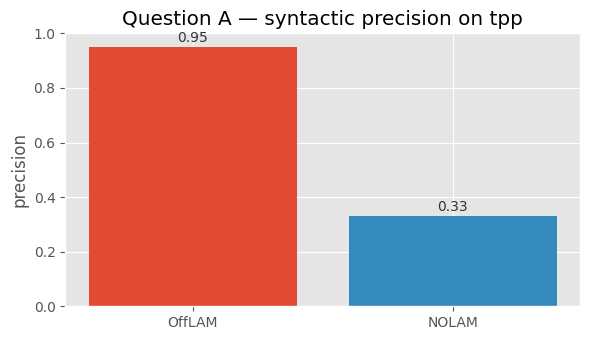

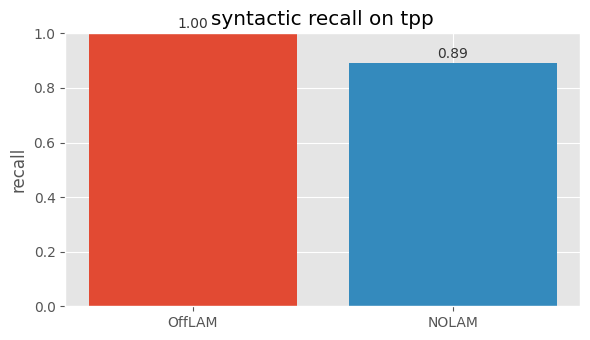

In [86]:
p_off = syntactic_precision(domain_offlam_path, domain_path)['mean']
p_nol = syntactic_precision(domain_nolam_path , domain_path)['mean']
r_off = syntactic_recall(domain_offlam_path, domain_path)['mean']
r_nol = syntactic_recall(domain_nolam_path , domain_path)['mean']

bar_compare({'OffLAM': p_off, 'NOLAM': p_nol},
            title='Question A — syntactic precision on tpp', ylabel='precision')
bar_compare({'OffLAM': r_off, 'NOLAM': r_nol},
            title='syntactic recall on tpp', ylabel='recall')

if   p_off > p_nol + 1e-6: winner_a = "OffLAM wins"
elif p_nol > p_off + 1e-6: winner_a = "NOLAM wins"
else:                       winner_a = "It's a tie"

reveal(poll_qa, winner_a,
       formatter=lambda w: f"{w}  (OffLAM={p_off:.3f}, NOLAM={p_nol:.3f})")

#### 🔍 Where did they disagree? Diff each learned model against the reference.

In [87]:
print('--- OffLAM vs reference ---')
html_side_by_side(domain_offlam_path, domain_path, 'OffLAM', 'Reference')

--- OffLAM vs reference ---


In [88]:
print('--- NOLAM vs reference ---')
html_side_by_side(domain_nolam_path, domain_path, 'NOLAM', 'Reference')

--- NOLAM vs reference ---


## 5. Question B: SAM vs. OffLAM on **goldminer** (solving ratio)

Same trajectories, different question. **Who produces a model that solves more
planning problems?**

In [89]:
poll_qb = make_poll(
    "Who do you bet on?",
    ["SAM wins", "OffLAM wins", "It's a tie"],
)

RadioButtons(layout=Layout(width='auto'), options=('SAM wins', 'OffLAM wins', "It's a tie"), value='SAM wins')

In [90]:
sam_b    = get_algorithm('sam')
offlam_b = get_algorithm('offlam')

domain_path_b      = get_domain_path('goldminer')
domain_empty_b     = empty_domain(domain_path_b)
traj_paths_b       = get_trajectories_path('goldminer')

model_sam_b    = sam_b   .learn(domain_empty_b, traj_paths_b)
model_offlam_b = offlam_b.learn(domain_empty_b, traj_paths_b)

sam_path_b    = 'sam_goldminer.pddl'
offlam_path_b = 'offlam_goldminer.pddl'
with open(sam_path_b   , 'w') as f: f.write(model_sam_b)
with open(offlam_path_b, 'w') as f: f.write(model_offlam_b)

[Info] Reading input action model from file empty.pddl
[Info] Initializing uncertain preconditions of move to the maximal superset of preconditions.
[Info] Initializing uncertain positive effects of move to the maximal superset of possible effects.
[Info] Initializing uncertain negative effects of move to the maximal superset of possible effects.
[Info] Initializing uncertain preconditions of pickup_laser to the maximal superset of preconditions.
[Info] Initializing uncertain positive effects of pickup_laser to the maximal superset of possible effects.
[Info] Initializing uncertain negative effects of pickup_laser to the maximal superset of possible effects.
[Info] Initializing uncertain preconditions of pickup_bomb to the maximal superset of preconditions.
[Info] Initializing uncertain positive effects of pickup_bomb to the maximal superset of possible effects.
[Info] Initializing uncertain negative effects of pickup_bomb to the maximal superset of possible effects.
[Info] Initializin

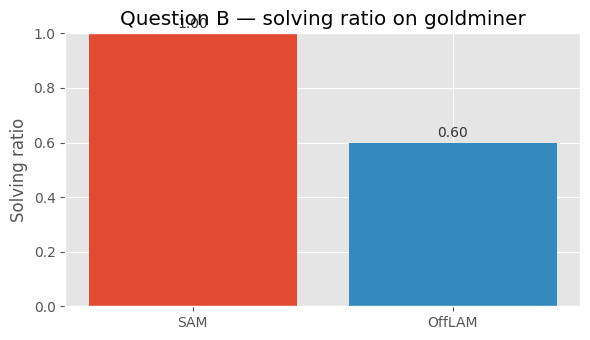

In [91]:
probs_b = get_problems_path('goldminer', kind='solving')

m_sam    = problem_solving(sam_path_b   , domain_path_b, probs_b, timeout=60, show_progress=False)
m_offlam = problem_solving(offlam_path_b, domain_path_b, probs_b, timeout=60, show_progress=False)

s_sam    = m_sam.get('solving_ratio', m_sam   .get('solving', 0.0))
s_offlam = m_offlam.get('solving_ratio', m_offlam.get('solving', 0.0))

bar_compare({'SAM': s_sam, 'OffLAM': s_offlam},
            title='Question B — solving ratio on goldminer', ylabel='Solving ratio')

if   s_sam   > s_offlam: winner_b = "SAM wins"
elif s_offlam > s_sam: winner_b = "OffLAM wins"
else: winner_b = "It's a tie"

reveal(poll_qb, winner_b,
       formatter=lambda w: f"{w}  (SAM={s_sam:.3f}, OffLAM={s_offlam:.3f})")

In [ ]:
html_side_by_side(offlam_path_b, domain_path_b, 'OffLAM', 'Reference')

In [ ]:
html_side_by_side(sam_path_b, domain_path_b, 'SAM', 'Reference')

## 6. Final challenge: the leaderboard 🏆

Pick a **domain**, pick an **algorithm**, and
submit your run. Your **solving ratio** on the test problems is your score.

Submissions accumulate in the leaderboard below. Whoever's at the top when the
session ends wins.

*Tip:* try a domain you haven't seen yet — `parking`, ...

In [ ]:
from amlgym.benchmarks import get_domain_names

ALL_DOMAINS    = sorted(get_domain_names())
ALL_ALGORITHMS = ["sam", "offlam", "nolam", "rosame"]

leaderboard = []  # accumulating list of dicts

def _score(algo_name, domain_name):
    learner   = get_algorithm(algo_name)
    dom_path  = get_domain_path(domain_name)
    dom_empty = empty_domain(dom_path)
    trajs     = get_trajectories_path(domain_name)
    model = learner.learn(dom_empty, trajs)
    out_path = f"leaderboard_{algo_name}_{domain_name}.pddl"
    with open(out_path, "w") as f:
        f.write(model)

    print(f"Computing problem solving ratio of {algo} on {dom} ...")
    probs = get_problems_path(domain_name, kind="solving")
    m = problem_solving(out_path, dom_path, probs,
                        timeout=3, show_progress=False)
    return m.get("solving_ratio", m.get("solving", 0.0)), m

name_w = widgets.Text(value="", placeholder="Your name / team",
                      description="Name:")
dom_w  = widgets.Dropdown(options=ALL_DOMAINS, value=ALL_DOMAINS[0],
                          description="Domain:")
algo_w = widgets.Dropdown(options=ALL_ALGORITHMS, value="sam",
                          description="Algorithm:")
go_btn = widgets.Button(description="🚀 Submit run",
                        button_style="success")
out_w  = widgets.Output()

def _on_click(_):
    out_w.clear_output()
    with out_w:
        nm = name_w.value.strip() or "anonymous"
        algo, dom = algo_w.value, dom_w.value
        print(f"Running {algo} on {dom} ...")
        try:
            s, _ = _score(algo, dom)
        except Exception as e:
            print("Run failed:", e)
            return
        leaderboard.append({
            "name": nm, "algorithm": algo, "domain": dom,
            "solving_ratio": round(s, 3),
        })
        df = (pd.DataFrame(leaderboard)
                .sort_values("solving_ratio", ascending=False)
                .reset_index(drop=True))
        df.index = df.index + 1
        display(Markdown("### 🏆 Leaderboard"))
        display(df)

go_btn.on_click(_on_click)
display(widgets.VBox([name_w, dom_w, algo_w, go_btn, out_w]))


### Closing thoughts

We have now seen the full cycle: pick a domain and associated training set of trajectories, pick a learning algorithm, learn a domain, evaluate the domain by measuring syntactic, solving, and predictive power metrics. Two ideas worth taking home:

- **The right algorithm depends on the data you actually have.** SAM is powerful when traces are fully observable; OffLAM when they are partially observable; NOLAM when state observations are noisy.
- **Syntactic, solving and predictive power metrics are complementary.** For example: a model can be syntactically imperfect but still solve every test problem. Evaluate against the task you care about.

Thanks for playing!